In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('customers.csv')
feature_cols = ['Income', 'DebtIncomeRatio']
X_raw = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [ ]:
linkage_methods = {
    'Single linkage (Минимальное расстояние)': 'single',
    'Complete linkage (Максимальное расстояние)': 'complete',
    'Group average (Среднее расстояние)': 'average',
    'Ward distance (Минимизация дисперсии)': 'ward'
}

n_clusters = 5

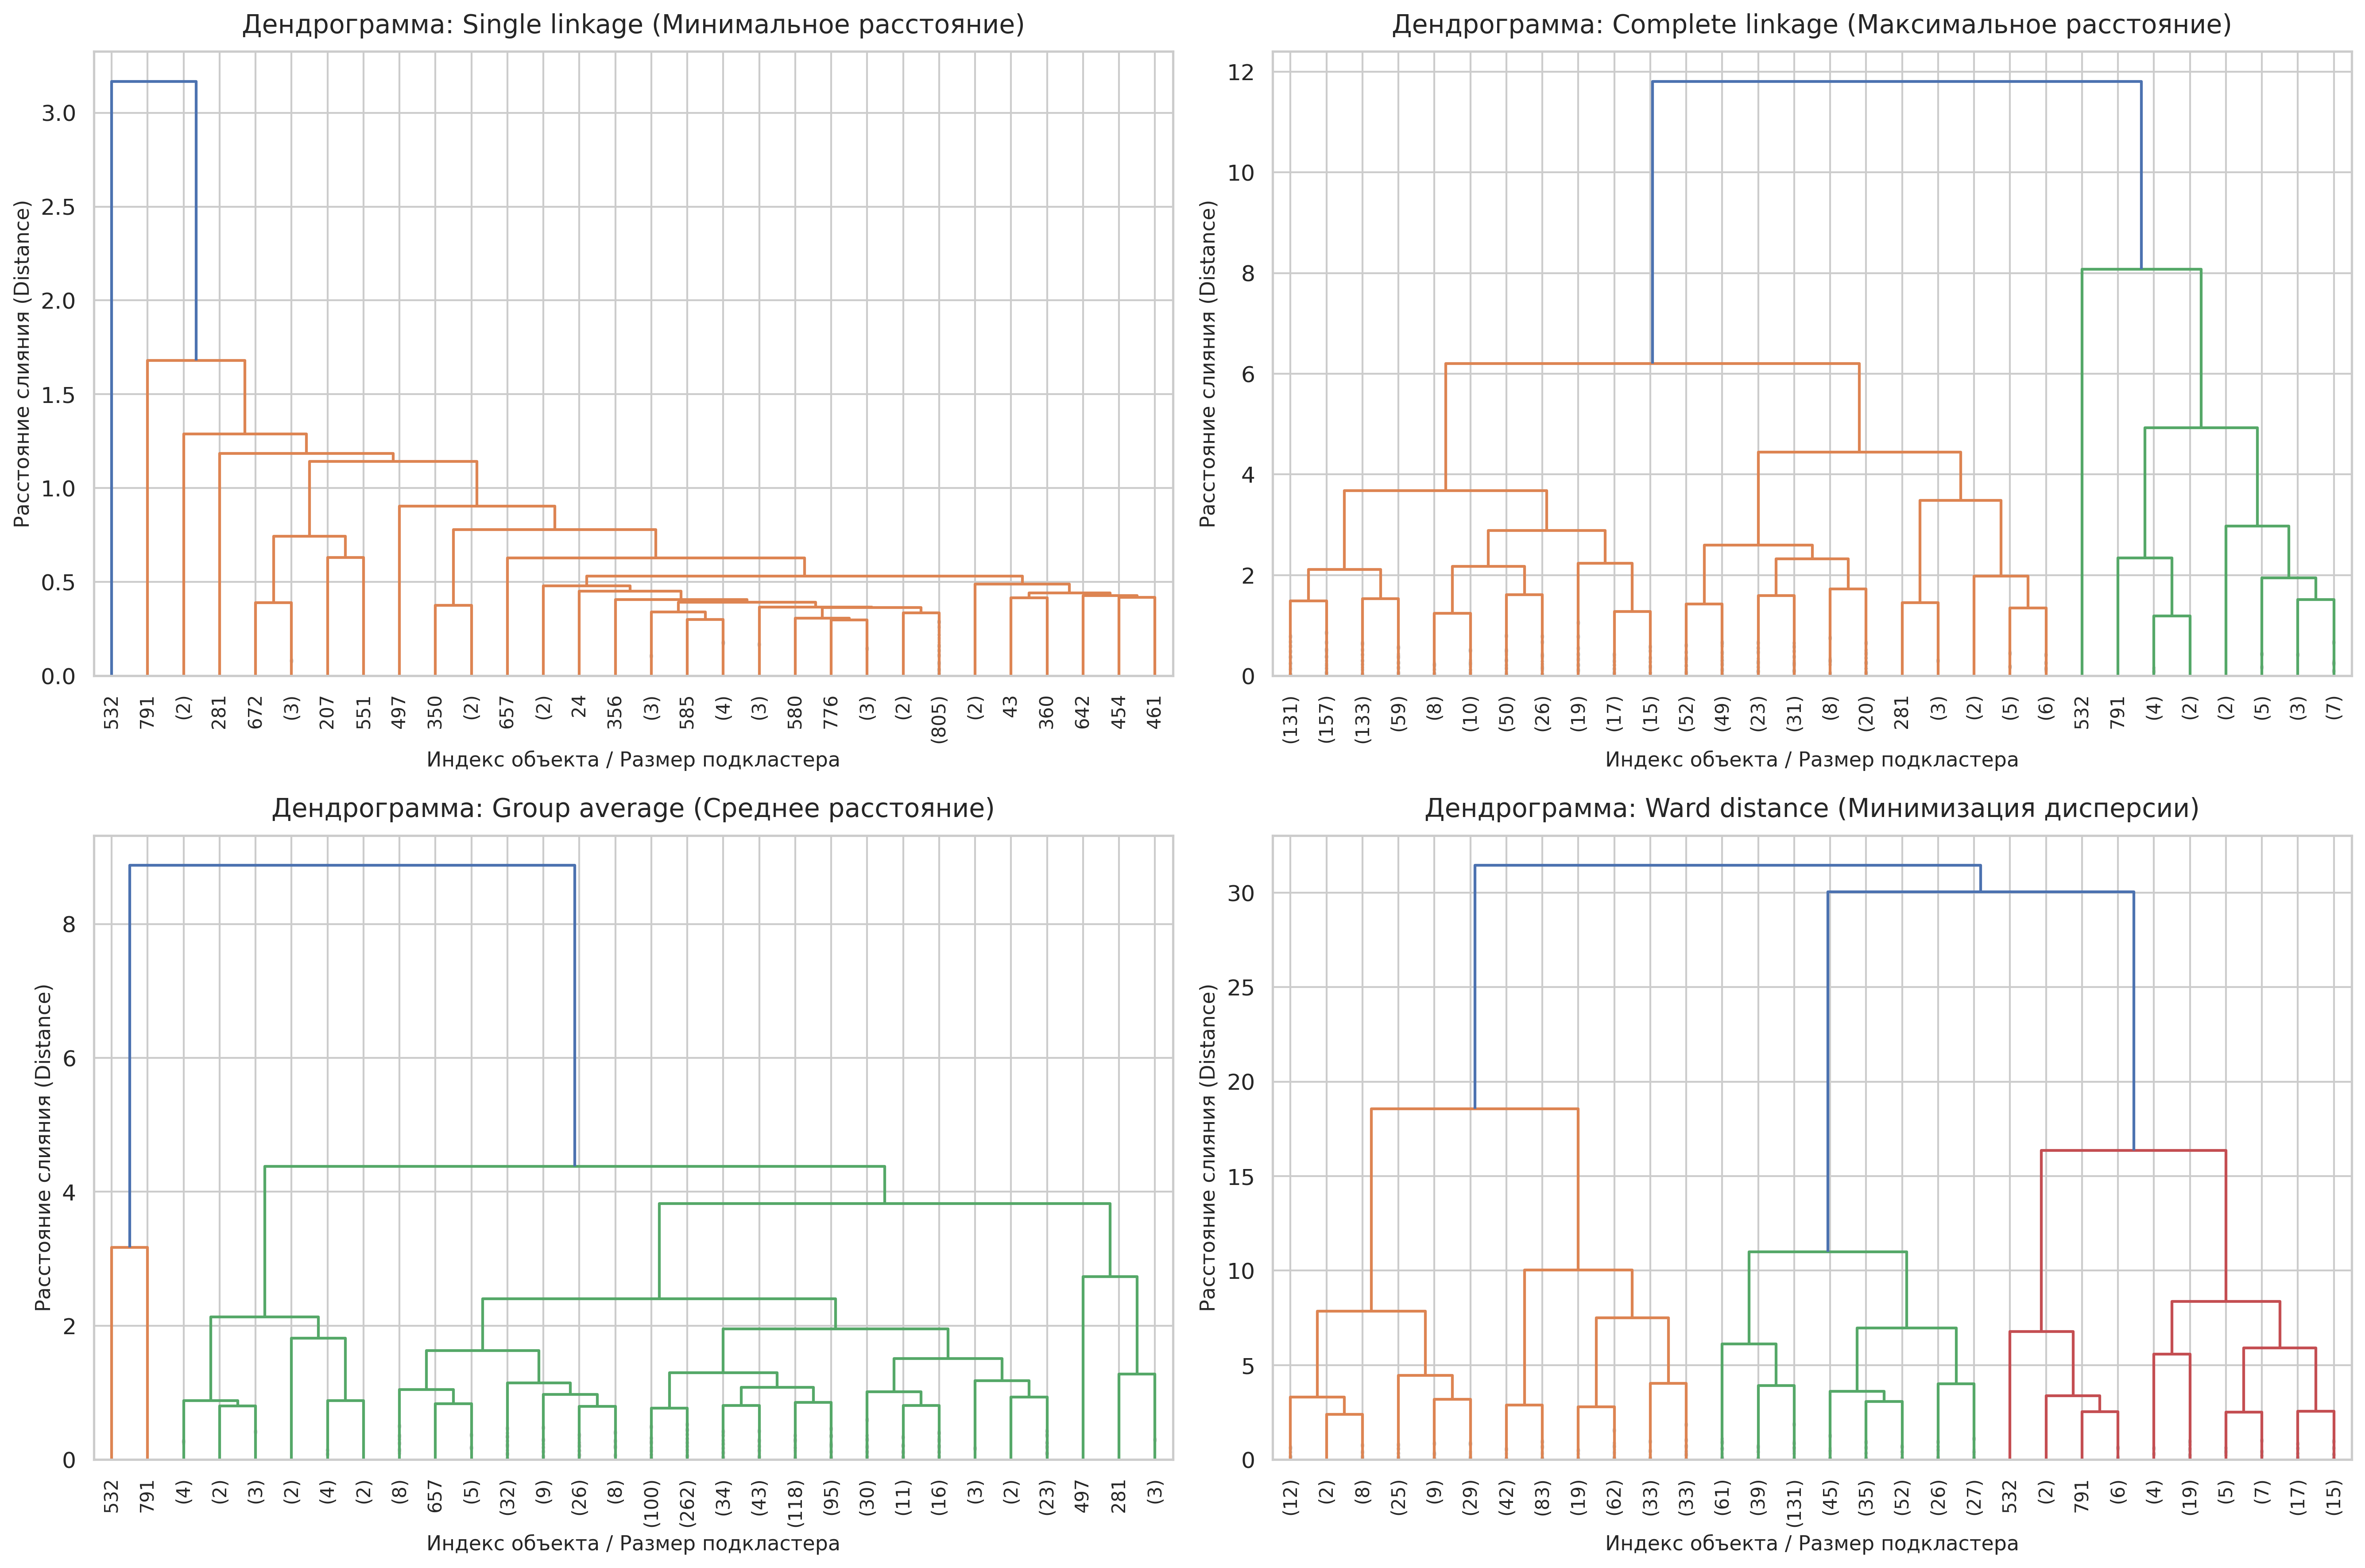

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(2, 2, figsize=(18, 12), dpi=300)
axes = axes.flatten()

linkage_matrices = {}

for idx, (title, method) in enumerate(linkage_methods.items()):
    Z = linkage(X_scaled, method=method, metric='euclidean')
    linkage_matrices[method] = Z

    dendrogram(
        Z,
        ax=axes[idx],
        truncate_mode='lastp',
        p=30,
        leaf_rotation=90.,
        leaf_font_size=10.,
        show_contracted=True
    )
    axes[idx].set_title(f"Дендрограмма: {title}", fontsize=14, pad=10)
    axes[idx].set_xlabel("Индекс объекта / Размер подкластера", fontsize=11)
    axes[idx].set_ylabel("Расстояние слияния (Distance)", fontsize=11)

plt.tight_layout()
plt.savefig('dendrograms_comparison.png', dpi=300)
plt.show()

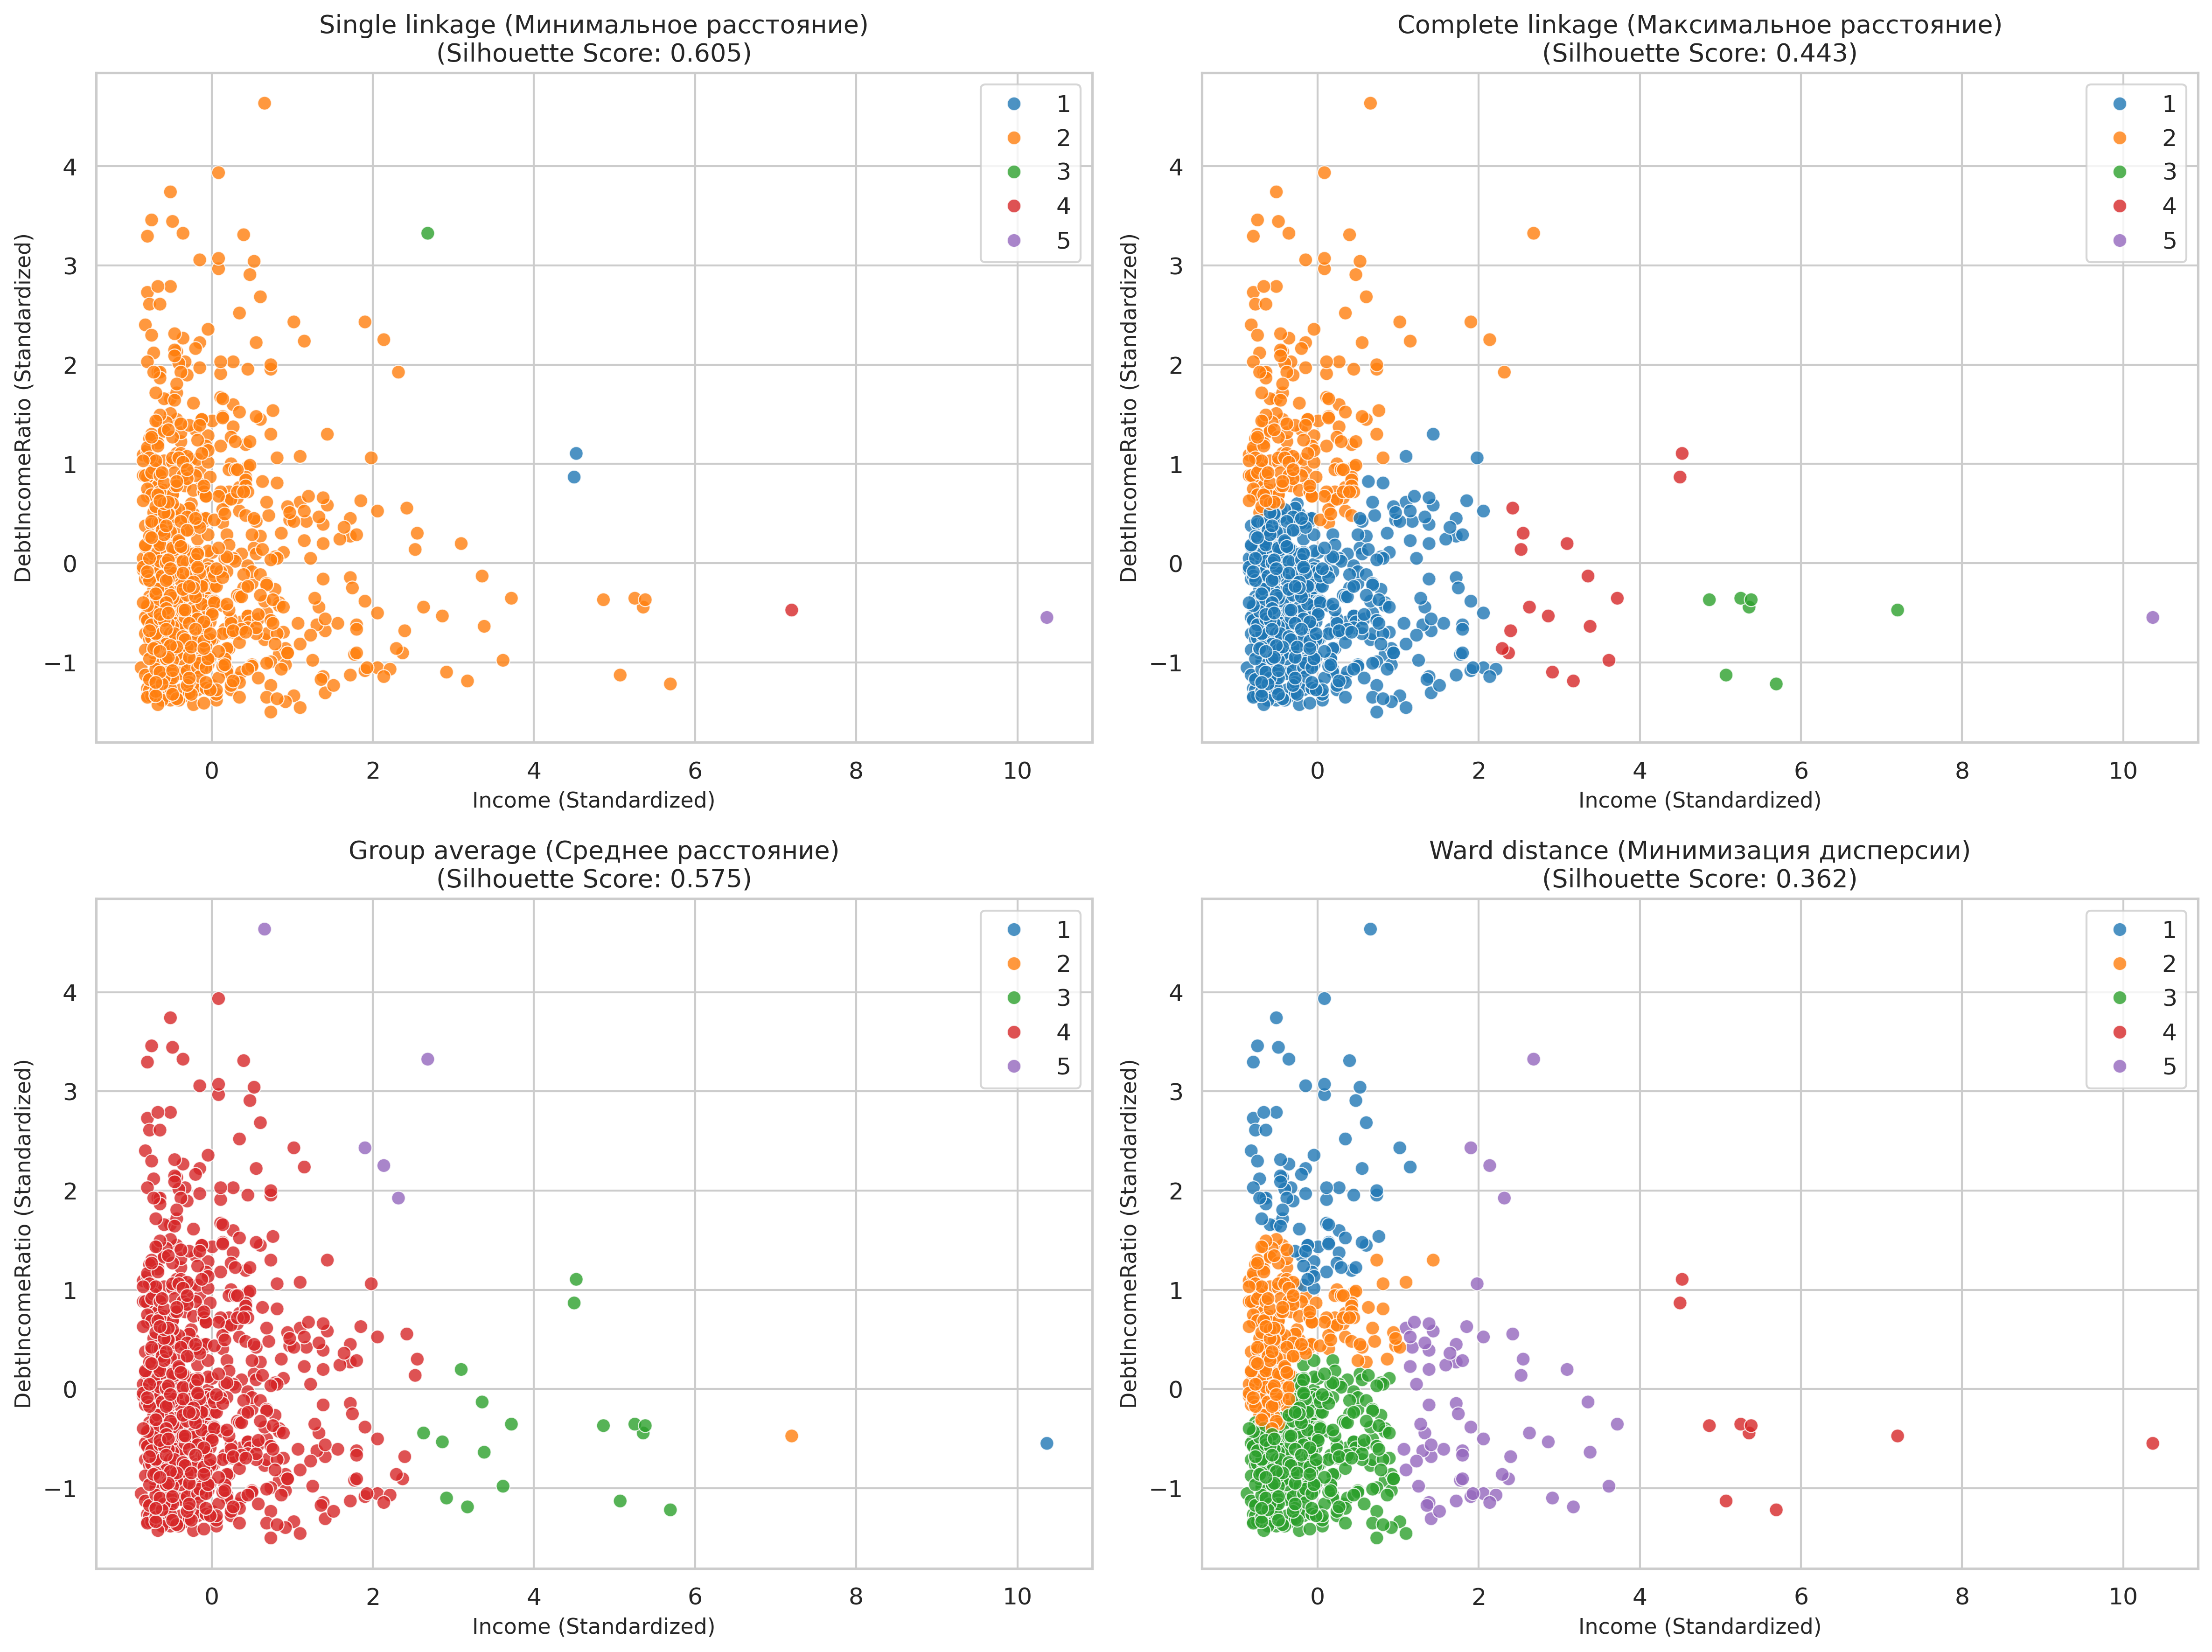

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
axes = axes.flatten()

metrics_summary = []

for idx, (title, method) in enumerate(linkage_methods.items()):
    Z = linkage_matrices[method]
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    sil_score = silhouette_score(X_scaled, labels)
    metrics_summary.append({'Method': title, 'Silhouette Score': sil_score})

    sns.scatterplot(
        x=X_scaled[:, 0], y=X_scaled[:, 1],
        hue=labels, palette='tab10',
        ax=axes[idx], s=50, alpha=0.8, legend='full'
    )
    axes[idx].set_title(f"{title}\n(Silhouette Score: {sil_score:.3f})", fontsize=13)
    axes[idx].set_xlabel("Income (Standardized)", fontsize=11)
    axes[idx].set_ylabel("DebtIncomeRatio (Standardized)", fontsize=11)

plt.tight_layout()
plt.savefig('hierarchical_clusters_plane.png', dpi=300)
plt.show()